### Image Denoising with Autoencoders

We will implement a simple convolutional autoencoder to denoise images. The process will involve:
1.  **Loading and preparing the dataset**: Using the MNIST dataset.
2.  **Adding noise**: Corrupting the images to simulate a denoising task.
3.  **Building the Autoencoder**: Defining the encoder and decoder architecture.
4.  **Training the Autoencoder**: Training the model to reconstruct clean images from noisy ones.
5.  **Evaluating the results**: Visualizing the denoised images.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
import matplotlib.pyplot as plt

### 1. Load and Prepare Data

We'll use the MNIST dataset of handwritten digits. We'll normalize the pixel values to be between 0 and 1, and then reshape them for convolutional layers.

In [2]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = datasets.mnist.load_data()

# Normalize and reshape the data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape data to add a channel dimension (for grayscale images, it's 1)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


### 2. Add Noise to Images

We'll add random Gaussian noise to our training and test images. The autoencoder will be trained to remove this noise.

In [3]:
# Define noise parameters
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip values to ensure they remain within [0, 1] range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

### Visualize Original, Noisy, and Clean Images

Let's take a look at a few examples of the original images, their noisy counterparts, and what the autoencoder will aim to reconstruct (the clean original images).

### 3. Build the Autoencoder

We'll construct a convolutional autoencoder. The encoder will reduce the dimensionality of the input images, and the decoder will reconstruct them. We'll use `Conv2D` layers for encoding and `Conv2DTranspose` layers for decoding.

In [5]:
# Encoder
encoder_input = tf.keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
decoder_input = encoded
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(decoder_input)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = models.Model(encoder_input, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### 4. Train the Autoencoder

We will train the autoencoder using the `x_train_noisy` as input and `x_train` (the clean images) as the target output. This will enable the model to learn to reconstruct clean images from noisy ones.

In [6]:
history = autoencoder.fit(x_train_noisy, x_train,
                          epochs=10,
                          batch_size=128,
                          shuffle=True,
                          validation_data=(x_test_noisy, x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 77s 159ms/step - loss: 0.1631 - val_loss: 0.1155
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 167ms/step - loss: 0.1118 - val_loss: 0.1069
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 78s 158ms/step - loss: 0.1065 - val_loss: 0.1037
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 73s 156ms/step - loss: 0.1040 - val_loss: 0.1022
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 74s 157ms/step - loss: 0.1023 - val_loss: 0.1007
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 157ms/step - loss: 0.1011 - val_loss: 0.1000
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 152ms/step - loss: 0.1002 - val_loss: 0.0988
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 71s 152ms/step - loss: 0.0993 - val_loss: 0.0980
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 155ms/step - loss: 0.0987 - val_loss: 0.0975
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 72s 155ms/step - loss: 0.0980 - val_loss: 0.0970


### 5. Evaluate the Results

After training, we will use the trained autoencoder to predict denoised images from the noisy test set and then visualize them alongside the original and noisy images to assess its performance.

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


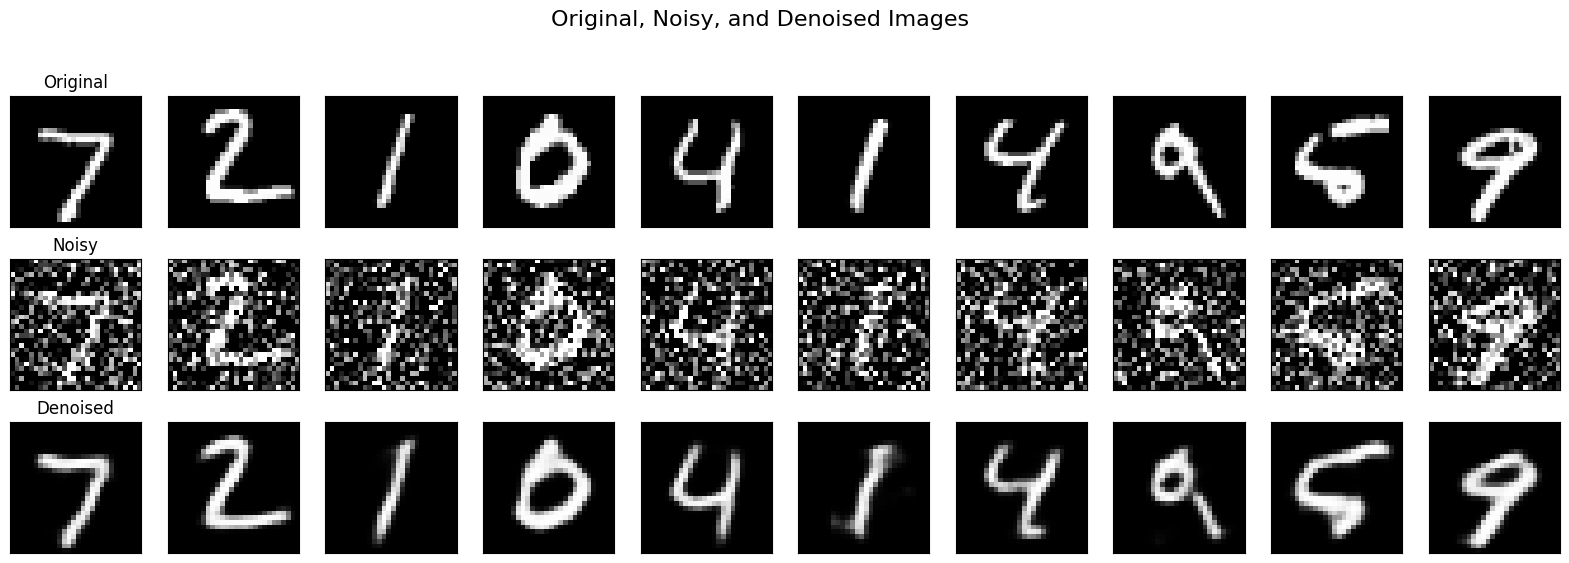

In [7]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    # Display noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Noisy")

    # Display reconstruction
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Denoised")
plt.suptitle('Original, Noisy, and Denoised Images', y=1.02, fontsize=16)
plt.show()

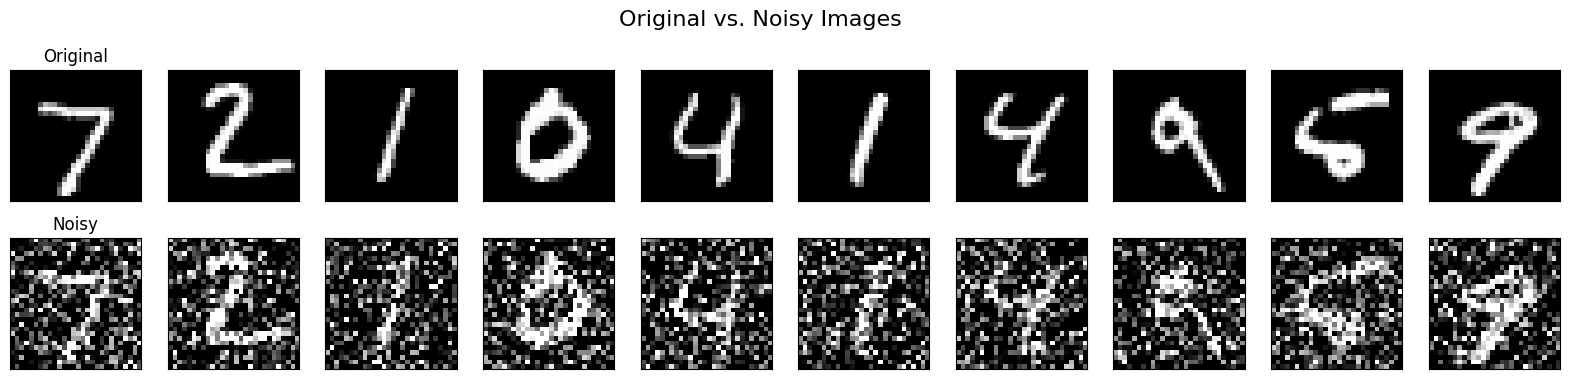

In [4]:
n = 10 # How many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Original")

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_title("Noisy")
plt.suptitle('Original vs. Noisy Images', y=1.02, fontsize=16)
plt.show()